# Kaggle

Во многих из уроков мы использовали датасет Titanic - он был взят из одного из соревнований Kaggle. Так как это вводное соревнование, постоянно открытое как  для изучения платформы Kaggle, так и для совершенствования навыков участников, то естественно, что у него достаточно много обсуждений и публичных ядер. Предлагаем по [этой ссылке](https://inclass.kaggle.com/arthurtok/introduction-to-ensembling-stacking-in-python) открыть и изучить одно из самых популярных ядер, набравшее большинство голосов участников. Там представлен т.н. end-to-end ML pipeline - построение пайплайна ML, начиная с анализа данных и заканчивая моделью.

### Задание 1.

Скачайте ядро себе на компьютер и запустите ячейки с кодом. Изучите ядро, посмотрите, как автор использует стекинг в своей модели. В предыдущем модуле мы как раз изучали методы ансамбирования алгоритмов, поэтому посмотреть, как эти методы применяются разными людьми, будет полезно.

### Задание 2.

Если вы еще не зарегистрировались на сайте Kaggle, сделайте это. Затем пройдите по той же ссылке и скопируйте к себе это ядро. Удалите ячейки с текстом, все модели и импорт ненужных библиотек. Должны остаться только преобразования данных, графики и разделение на тренировочные и тестовый датасеты. Это пригодится в дальнейшем, когда вы будете выполнять домашнее задание.

Введение
Этот ноутбук — очень простой и базовый вводный материал по методу ансамблирования (объединения) базовых моделей обучения, в частности по варианту ансамблирования, известному как стекинг. Если кратко, стекинг использует на первом уровне (базовом) предсказания нескольких простых классификаторов, а затем применяет другую модель на втором уровне, чтобы предсказать итоговый результат на основе этих предсказаний первого уровня.

Набор данных Titanic — отличный кандидат для введения в эту концепцию, так как многие новички на Kaggle начинают именно с него. Более того, даже несмотря на то, что стекинг помогал многим командам побеждать в соревнованиях Kaggle, по этой теме, похоже, не так много доступных материалов, поэтому я надеюсь, что этот ноутбук хотя бы частично восполнит этот пробел.

Я сам довольно новичок в сообществе Kaggle, и первый полноценный скрипт для ансамблирования/стекинга, на который мне посчастливилось наткнуться и изучить, был написан великим Faron в соревновании AllState Severity Claims. Материалы этого ноутбука во многом заимствованы из скрипта Faron’а, хотя у него были ансамбли регрессоров, а здесь мы рассматриваем ансамбли классификаторов. В любом случае, рекомендую ознакомиться с его скриптом:

Stacking Starter : by Faron

Теперь перейдём к содержанию этого ноутбука — надеюсь, он сумеет достаточно просто и наглядно объяснить концепцию ансамблирования. Другой мой отдельный скрипт на Kaggle, который реализует те же самые шаги ансамблирования (но с другими параметрами), описанные ниже, даёт публичный результат LB 0.808, чего достаточно, чтобы войти в топ 9%, и при этом работает чуть меньше 4 минут. Поэтому я уверен, что этот скрипт можно ещё улучшить и развить. В любом случае, буду рад любым комментариям по поводу того, как можно сделать его лучше.

In [2]:
# Load in our libraries
import pandas as pd
import numpy as np
import re
import sklearn
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls

import warnings
warnings.filterwarnings('ignore')

# Going to use these 5 base models for the stacking
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, 
                              GradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.model_selection import KFold

Исследование, создание и очистка признаков

Теперь мы будем действовать так же, как построено большинство ноутбуков в целом: сначала исследуем имеющиеся данные, определим возможные варианты создания (инжиниринга) признаков, а также выполним численное кодирование всех категориальных признаков.

In [5]:
# Load in the train and test datasets
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

# Store our passenger ID for easy access
PassengerId = test['PassengerId']

train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


Ну, неудивительно, что наша задача — каким-то образом извлечь информацию из категориальных переменных.  

## Feature Engineering (Создание признаков)

Здесь стоит отдать должное очень содержательному и хорошо продуманному ноутбуку Сины за идеи по созданию признаков, так что, пожалуйста, ознакомьтесь с его работой:  

**Titanic Best Working Classifier : by Sina**

In [6]:
full_data = [train, test]

# Some features of my own that I have added in
# Gives the length of the name
train['Name_length'] = train['Name'].apply(len)
test['Name_length'] = test['Name'].apply(len)
# Feature that tells whether a passenger had a cabin on the Titanic
train['Has_Cabin'] = train["Cabin"].apply(lambda x: 0 if type(x) == float else 1)
test['Has_Cabin'] = test["Cabin"].apply(lambda x: 0 if type(x) == float else 1)

# Feature engineering steps taken from Sina
# Create new feature FamilySize as a combination of SibSp and Parch
for dataset in full_data:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
# Create new feature IsAlone from FamilySize
for dataset in full_data:
    dataset['IsAlone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1
# Remove all NULLS in the Embarked column
for dataset in full_data:
    dataset['Embarked'] = dataset['Embarked'].fillna('S')
# Remove all NULLS in the Fare column and create a new feature CategoricalFare
for dataset in full_data:
    dataset['Fare'] = dataset['Fare'].fillna(train['Fare'].median())
train['CategoricalFare'] = pd.qcut(train['Fare'], 4)
# Create a New feature CategoricalAge
for dataset in full_data:
    age_avg = dataset['Age'].mean()
    age_std = dataset['Age'].std()
    age_null_count = dataset['Age'].isnull().sum()
    age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count)
    dataset['Age'][np.isnan(dataset['Age'])] = age_null_random_list
    dataset['Age'] = dataset['Age'].astype(int)
train['CategoricalAge'] = pd.cut(train['Age'], 5)
# Define function to extract titles from passenger names
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    # If the title exists, extract and return it.
    if title_search:
        return title_search.group(1)
    return ""
# Create a new feature Title, containing the titles of passenger names
for dataset in full_data:
    dataset['Title'] = dataset['Name'].apply(get_title)
# Group all non-common titles into one single grouping "Rare"
for dataset in full_data:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

for dataset in full_data:
    # Mapping Sex
    dataset['Sex'] = dataset['Sex'].map( {'female': 0, 'male': 1} ).astype(int)
    
    # Mapping titles
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)
    
    # Mapping Embarked
    dataset['Embarked'] = dataset['Embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)
    
    # Mapping Fare
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] 						        = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare']   = 2
    dataset.loc[ dataset['Fare'] > 31, 'Fare'] 							        = 3
    dataset['Fare'] = dataset['Fare'].astype(int)
    
    # Mapping Age
    dataset.loc[ dataset['Age'] <= 16, 'Age'] 					       = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age'] = 4 ;

In [7]:
# Feature selection
drop_elements = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp']
train = train.drop(drop_elements, axis = 1)
train = train.drop(['CategoricalAge', 'CategoricalFare'], axis = 1)
test  = test.drop(drop_elements, axis = 1)

Хорошо, теперь, когда мы очистили признаки, извлекли релевантную информацию и удалили категориальные столбцы, все наши признаки должны быть числовыми — в формате, подходящем для подачи в наши модели машинного обучения.  

Однако, прежде чем продолжить, давайте построим несколько простых графиков корреляции и распределения для нашего преобразованного набора данных, чтобы увидеть, как они выглядят.  

## Visualisations (Визуализации)

In [8]:
train.head(3)

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked,Name_length,Has_Cabin,FamilySize,IsAlone,Title
0,0,3,1,1,0,0,0,23,0,2,0,1
1,1,1,0,2,0,3,1,51,1,2,0,3
2,1,3,0,1,0,1,0,22,0,1,1,2


## Карта корреляций Пирсона

Давайте построим графики корреляции признаков, чтобы понять, насколько один признак связан с другим.  

Для этого мы воспользуемся библиотекой визуализации **Seaborn**, которая позволяет очень удобно строить **тепловые карты** (heatmaps), например, следующим образом:


<Axes: title={'center': 'Pearson Correlation of Features'}>

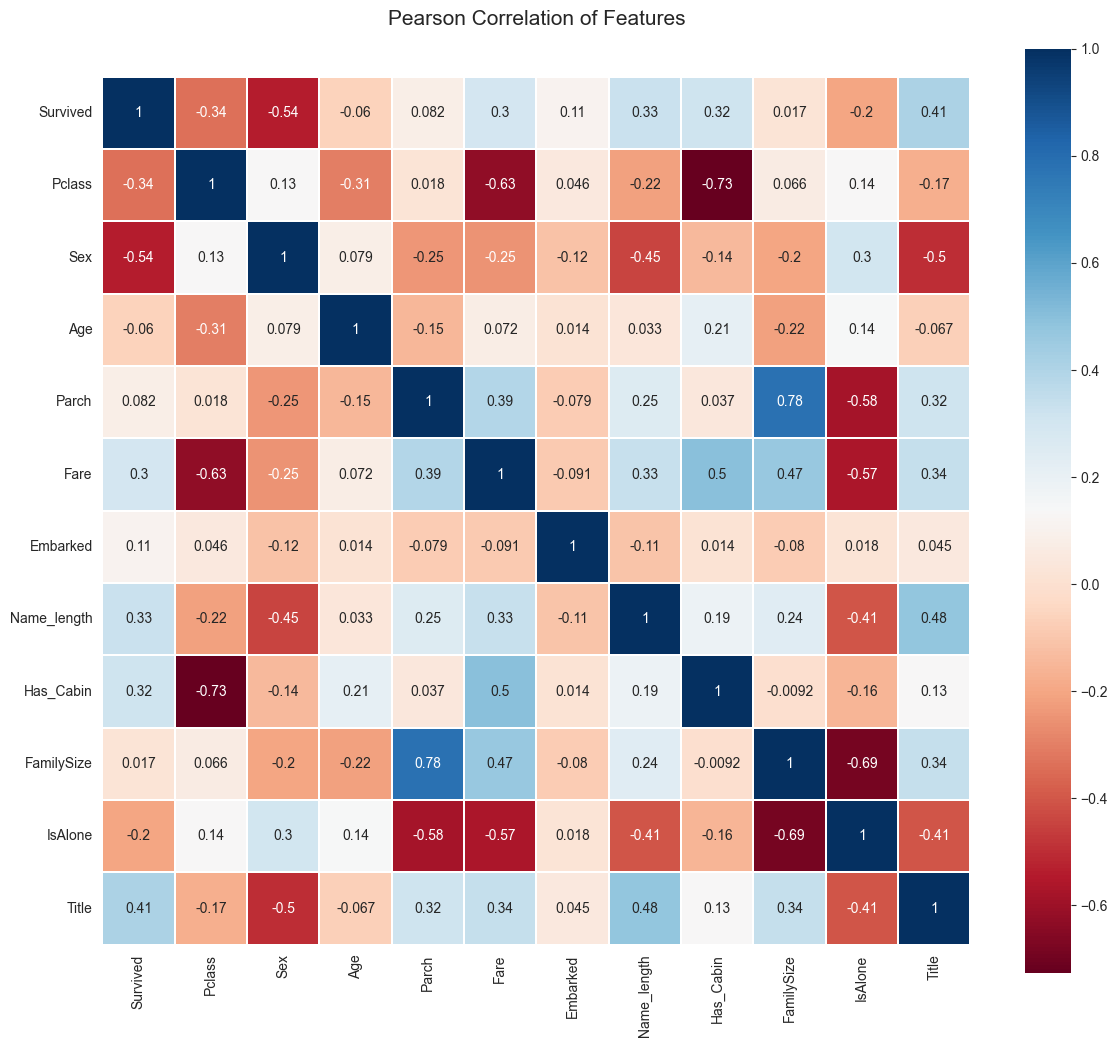

In [9]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(train.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)

## Выводы из графиков

Одна из вещей, которую может показать нам карта корреляций Пирсона, заключается в том, что среди признаков нет слишком большого числа сильно коррелированных между собой.  

С точки зрения подачи этих признаков в модель обучения это хорошо, потому что это означает, что в нашем обучающем наборе нет большого количества избыточных или лишних данных, и каждый признак несёт в себе некоторую уникальную информацию.  

Наиболее коррелированные признаки в нашем случае — это **размер семьи (Family size)** и **Parch** (родители и дети). Тем не менее, для целей данного упражнения я оставлю оба признака.  

## Pairplots (Парные графики)

Напоследок давайте построим **pairplot**-ы, чтобы наблюдать распределение данных между парами признаков. И снова для этого мы воспользуемся библиотекой **Seaborn**.


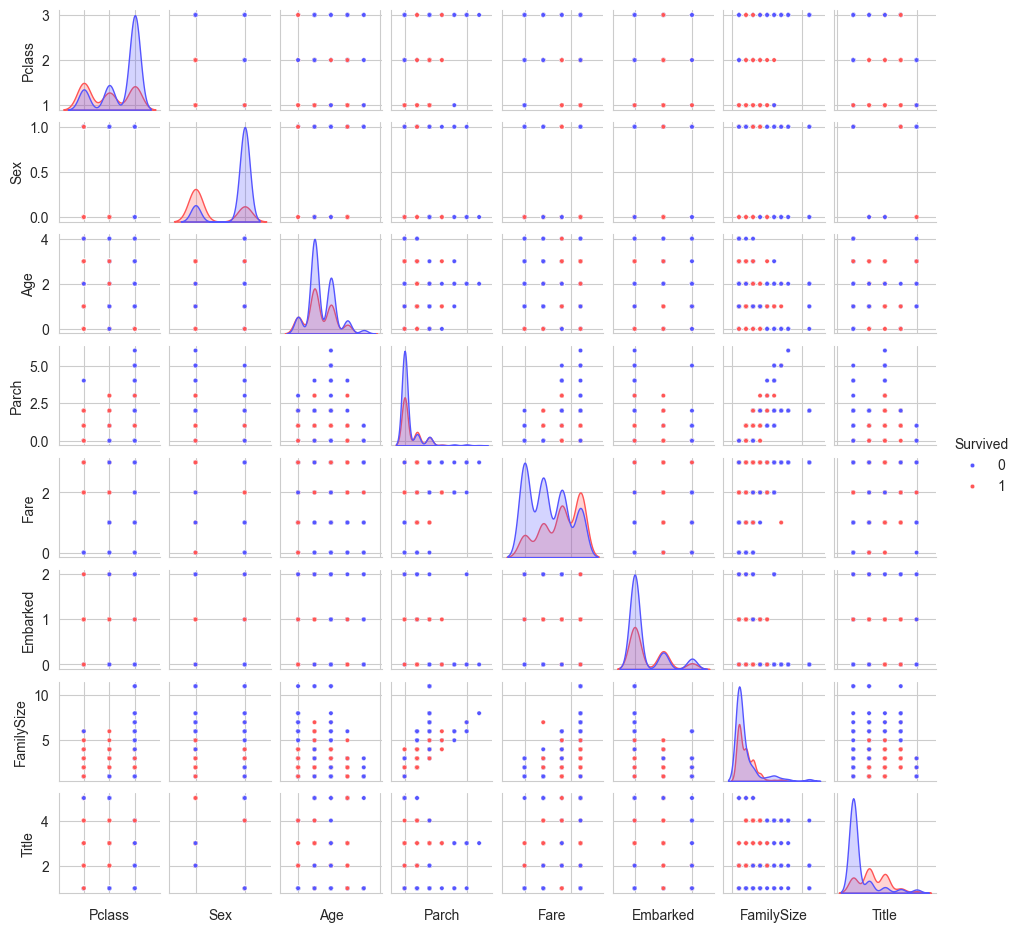

In [10]:
g = sns.pairplot(train[[u'Survived', u'Pclass', u'Sex', u'Age', u'Parch', u'Fare', u'Embarked',
       u'FamilySize', u'Title']], hue='Survived', palette = 'seismic',size=1.2,diag_kind = 'kde',diag_kws=dict(shade=True),plot_kws=dict(s=10) )
g.set(xticklabels=[])

## Ансамблирование и стекинг моделей

Наконец, после короткого, но насыщенного отступления, посвящённого **feature engineering** и форматированию данных, мы подходим к основной сути этого ноутбука.

### Создаём ансамбль на основе стекинга!

---

## Вспомогательные классы в Python

Здесь мы используем возможности **классов Python**, чтобы сделать процесс более удобным.  

Для новичков в программировании: классы обычно упоминаются в контексте **объектно-ориентированного программирования (OOP)**.  
Вкратце, класс помогает расширять код/программу для создания объектов (по-старому — переменных), а также реализовывать функции и методы, специфичные для этого класса.

В коде ниже мы создаём класс **`SklearnHelper`**, который расширяет встроенные методы (`train`, `predict`, `fit` и т.д.), общие для всех классификаторов библиотеки **Scikit-learn**.  

Это позволяет избежать повторяющегося кода — нам не придётся писать одни и те же методы пять раз, если мы захотим использовать пять разных классификаторов.


In [11]:
# Some useful parameters which will come in handy later on
ntrain = train.shape[0]
ntest = test.shape[0]
SEED = 0 # for reproducibility
NFOLDS = 5 # set folds for out-of-fold prediction
kf = KFold(n_splits= NFOLDS, shuffle=True, random_state=SEED)

# Class to extend the Sklearn classifier
class SklearnHelper(object):
    def __init__(self, clf, seed=0, params=None):
        params['random_state'] = seed
        self.clf = clf(**params)

    def train(self, x_train, y_train):
        self.clf.fit(x_train, y_train)

    def predict(self, x):
        return self.clf.predict(x)
    
    def fit(self,x,y):
        return self.clf.fit(x,y)
    
    def feature_importances(self,x,y):
        print(self.clf.fit(x,y).feature_importances_)
    
# Class to extend XGboost classifer

Для тех, кто уже знаком с этим, пояснять не нужно, а для новичков в Python: давайте разберём, что делает приведённый выше код.  

При создании базовых классификаторов я буду использовать только модели из библиотеки **Sklearn**, поэтому класс расширяется именно для них.  

### Конструктор `__init__`

`__init__` — стандартный конструктор Python. Он вызывается при создании объекта класса (например, классификатора).  

Аргументы:  
- `clf` — какой классификатор Sklearn использовать,  
- `seed` — случайное зерно для воспроизводимости,  
- `params` — параметры для выбранного классификатора.  

### Методы класса

Остальной код класса — это методы, которые просто вызывают соответствующие методы встроенных классификаторов Sklearn (`fit`, `predict` и т.д.).  

Иными словами, мы создали **обёртку (wrapper) вокруг Sklearn-классификаторов**, чтобы избежать повторного написания одинакового кода при использовании нескольких моделей в стекинге.  

---

## Out-of-Fold Predictions (Предсказания вне фолдов)

Как было упомянуто в вводной части, стекинг использует **предсказания базовых классификаторов** в качестве входа для обучения модели второго уровня.  

Однако нельзя просто обучить базовые модели на всём тренировочном наборе, получить предсказания на тесте и использовать их для второго уровня.  

Почему: так базовая модель уже "увидела" тестовые данные, и при использовании этих предсказаний для обучения второго уровня возникает риск **переобучения**.


In [12]:
def get_oof(clf, x_train, y_train, x_test):
    oof_train = np.zeros((ntrain,))
    oof_test = np.zeros((ntest,))
    oof_test_skf = np.empty((NFOLDS, ntest))

    for i, (train_index, test_index) in enumerate(kf.split(x_train)):
        x_tr = x_train[train_index]
        y_tr = y_train[train_index]
        x_te = x_train[test_index]

        clf.train(x_tr, y_tr)

        oof_train[test_index] = clf.predict(x_te)
        oof_test_skf[i, :] = clf.predict(x_test)

    oof_test[:] = oof_test_skf.mean(axis=0)
    return oof_train.reshape(-1, 1), oof_test.reshape(-1, 1)

## Генерация наших базовых моделей первого уровня

Теперь подготовим **пять моделей обучения** для первого уровня классификации. Эти модели удобно использовать через библиотеку **Sklearn**. Список моделей:

- **Random Forest classifier**  
- **Extra Trees classifier**  
- **AdaBoost classifier**  
- **Gradient Boosting classifier**  
- **Support Vector Machine (SVM)**  

### Параметры

Небольшое резюме основных параметров, которые мы будем указывать для полноты картины:

- **n_jobs** — количество ядер, используемых для обучения. Если установить `-1`, будут использованы все ядра.  
- **n_estimators** — количество деревьев в вашей модели (по умолчанию 10).  
- **max_depth** — максимальная глубина дерева, то есть насколько сильно может расширяться узел. Если задать слишком большое значение, есть риск переобучения.  
- **verbose** — управляет выводом текста во время обучения. `0` — подавление всего текста, `3` — вывод процесса обучения на каждом шаге.  

Полное описание всех параметров можно посмотреть на [официальном сайте Sklearn](https://scikit-learn.org/stable/supervised_learning.html). Там также можно найти множество других полезных параметров для настройки моделей.


In [13]:
# Put in our parameters for said classifiers
# Random Forest parameters
rf_params = {
    'n_jobs': -1,
    'n_estimators': 500,
     'warm_start': True, 
     #'max_features': 0.2,
    'max_depth': 6,
    'min_samples_leaf': 2,
    'max_features' : 'sqrt',
    'verbose': 0
}

# Extra Trees Parameters
et_params = {
    'n_jobs': -1,
    'n_estimators':500,
    #'max_features': 0.5,
    'max_depth': 8,
    'min_samples_leaf': 2,
    'verbose': 0
}

# AdaBoost parameters
ada_params = {
    'n_estimators': 500,
    'learning_rate' : 0.75
}

# Gradient Boosting parameters
gb_params = {
    'n_estimators': 500,
     #'max_features': 0.2,
    'max_depth': 5,
    'min_samples_leaf': 2,
    'verbose': 0
}

# Support Vector Classifier parameters 
svc_params = {
    'kernel' : 'linear',
    'C' : 0.025
    }

Кроме того, раз уж мы упомянули об объектах и классах в рамках парадигмы ООП, давайте теперь создадим 5 объектов, которые будут представлять наши 5 обучающих моделей, с помощью нашего вспомогательного класса Sklearn, который мы определили ранее.


In [14]:
# Create 5 objects that represent our 4 models
rf = SklearnHelper(clf=RandomForestClassifier, seed=SEED, params=rf_params)
et = SklearnHelper(clf=ExtraTreesClassifier, seed=SEED, params=et_params)
ada = SklearnHelper(clf=AdaBoostClassifier, seed=SEED, params=ada_params)
gb = SklearnHelper(clf=GradientBoostingClassifier, seed=SEED, params=gb_params)
svc = SklearnHelper(clf=SVC, seed=SEED, params=svc_params)

Создание массивов NumPy из наших обучающей и тестовой выборок

Отлично. Подготовив таким образом наши базовые модели первого уровня, мы теперь можем подготовить обучающие и тестовые данные для передачи в наши классификаторы, преобразовав их исходные датафреймы в массивы NumPy следующим образом:


In [15]:
# Create Numpy arrays of train, test and target ( Survived) dataframes to feed into our models
y_train = train['Survived'].ravel()
train = train.drop(['Survived'], axis=1)
x_train = train.values # Creates an array of the train data
x_test = test.values # Creats an array of the test data

Вывод предсказаний первого уровня

Теперь мы передаём обучающие и тестовые данные в наши 5 базовых классификаторов и используем функцию Out-of-Fold предсказаний, которую мы определили ранее, чтобы сгенерировать предсказания первого уровня. Дайте несколько минут, чтобы следующий блок кода выполнился.


In [16]:
# Create our OOF train and test predictions. These base results will be used as new features
et_oof_train, et_oof_test = get_oof(et, x_train, y_train, x_test) # Extra Trees
rf_oof_train, rf_oof_test = get_oof(rf,x_train, y_train, x_test) # Random Forest
ada_oof_train, ada_oof_test = get_oof(ada, x_train, y_train, x_test) # AdaBoost 
gb_oof_train, gb_oof_test = get_oof(gb,x_train, y_train, x_test) # Gradient Boost
svc_oof_train, svc_oof_test = get_oof(svc,x_train, y_train, x_test) # Support Vector Classifier

print("Training is complete")

Training is complete


Важность признаков, полученная из различных классификаторов

Теперь, обучив наши классификаторы первого уровня, мы можем воспользоваться очень удобной функцией моделей Sklearn — выводом значимости различных признаков в обучающем и тестовом наборах с помощью одной простой строки кода.

Согласно документации Sklearn, большинство классификаторов имеют встроенный атрибут, который возвращает важность признаков при простом вызове `.feature_importances_`. Поэтому мы воспользуемся этим полезным атрибутом через нашу функцию, определённую ранее, и построим график важности признаков.


In [17]:
rf_feature = rf.feature_importances(x_train,y_train)
et_feature = et.feature_importances(x_train, y_train)
ada_feature = ada.feature_importances(x_train, y_train)
gb_feature = gb.feature_importances(x_train,y_train)

[0.10461754 0.21062033 0.03368742 0.0186717  0.04797204 0.02955625
 0.12924628 0.04901102 0.07250635 0.01170459 0.29240648]
[0.11996816 0.37735315 0.02792461 0.01729503 0.0554205  0.02880661
 0.04771419 0.08456837 0.04433792 0.02091677 0.1756947 ]
[0.0330258  0.03292764 0.06049992 0.00291049 0.01265775 0.01790227
 0.13975452 0.05470319 0.41672847 0.00611768 0.22277226]
[0.08980073 0.01257553 0.05356977 0.01383066 0.04868551 0.02443402
 0.17290399 0.03672807 0.11124007 0.00516306 0.43106862]


Итак, я пока ещё не разобрался, как напрямую присвоить и сохранить значения важности признаков.  
Поэтому я просто выведу их с помощью кода выше, а затем вручную скопирую и вставлю в Python-списки, как показано ниже (простите за такой грубый хак).


In [18]:
rf_features = [0.10474135,  0.21837029,  0.04432652,  0.02249159,  0.05432591,  0.02854371
  ,0.07570305,  0.01088129 , 0.24247496,  0.13685733 , 0.06128402]
et_features = [ 0.12165657,  0.37098307  ,0.03129623 , 0.01591611 , 0.05525811 , 0.028157
  ,0.04589793 , 0.02030357 , 0.17289562 , 0.04853517,  0.08910063]
ada_features = [0.028 ,   0.008  ,      0.012   ,     0.05866667,   0.032 ,       0.008
  ,0.04666667 ,  0.     ,      0.05733333,   0.73866667,   0.01066667]
gb_features = [ 0.06796144 , 0.03889349 , 0.07237845 , 0.02628645 , 0.11194395,  0.04778854
  ,0.05965792 , 0.02774745,  0.07462718,  0.4593142 ,  0.01340093]

Создайте DataFrame из списков, содержащих данные о важности признаков,  
чтобы упростить построение графиков с помощью пакета Plotly.


In [19]:
cols = train.columns.values
# Create a dataframe with features
feature_dataframe = pd.DataFrame( {'features': cols,
     'Random Forest feature importances': rf_features,
     'Extra Trees  feature importances': et_features,
      'AdaBoost feature importances': ada_features,
    'Gradient Boost feature importances': gb_features
    })

Интерактивная визуализация важности признаков с помощью диаграмм рассеяния в Plotly

На этом этапе я использую интерактивный пакет Plotly, чтобы визуализировать значения важности признаков различных классификаторов с помощью диаграммы рассеяния, вызывая `Scatter` следующим образом:


In [20]:
# Scatter plot 
trace = go.Scatter(
    y = feature_dataframe['Random Forest feature importances'].values,
    x = feature_dataframe['features'].values,
    mode='markers',
    marker=dict(
        sizemode = 'diameter',
        sizeref = 1,
        size = 25,
#       size= feature_dataframe['AdaBoost feature importances'].values,
        #color = np.random.randn(500), #set color equal to a variable
        color = feature_dataframe['Random Forest feature importances'].values,
        colorscale='Portland',
        showscale=True
    ),
    text = feature_dataframe['features'].values
)
data = [trace]

layout= go.Layout(
    autosize= True,
    title= 'Random Forest Feature Importance',
    hovermode= 'closest',
#     xaxis= dict(
#         title= 'Pop',
#         ticklen= 5,
#         zeroline= False,
#         gridwidth= 2,
#     ),
    yaxis=dict(
        title= 'Feature Importance',
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig,filename='scatter2010')

# Scatter plot 
trace = go.Scatter(
    y = feature_dataframe['Extra Trees  feature importances'].values,
    x = feature_dataframe['features'].values,
    mode='markers',
    marker=dict(
        sizemode = 'diameter',
        sizeref = 1,
        size = 25,
#       size= feature_dataframe['AdaBoost feature importances'].values,
        #color = np.random.randn(500), #set color equal to a variable
        color = feature_dataframe['Extra Trees  feature importances'].values,
        colorscale='Portland',
        showscale=True
    ),
    text = feature_dataframe['features'].values
)
data = [trace]

layout= go.Layout(
    autosize= True,
    title= 'Extra Trees Feature Importance',
    hovermode= 'closest',
#     xaxis= dict(
#         title= 'Pop',
#         ticklen= 5,
#         zeroline= False,
#         gridwidth= 2,
#     ),
    yaxis=dict(
        title= 'Feature Importance',
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig,filename='scatter2010')

# Scatter plot 
trace = go.Scatter(
    y = feature_dataframe['AdaBoost feature importances'].values,
    x = feature_dataframe['features'].values,
    mode='markers',
    marker=dict(
        sizemode = 'diameter',
        sizeref = 1,
        size = 25,
#       size= feature_dataframe['AdaBoost feature importances'].values,
        #color = np.random.randn(500), #set color equal to a variable
        color = feature_dataframe['AdaBoost feature importances'].values,
        colorscale='Portland',
        showscale=True
    ),
    text = feature_dataframe['features'].values
)
data = [trace]

layout= go.Layout(
    autosize= True,
    title= 'AdaBoost Feature Importance',
    hovermode= 'closest',
#     xaxis= dict(
#         title= 'Pop',
#         ticklen= 5,
#         zeroline= False,
#         gridwidth= 2,
#     ),
    yaxis=dict(
        title= 'Feature Importance',
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig,filename='scatter2010')

# Scatter plot 
trace = go.Scatter(
    y = feature_dataframe['Gradient Boost feature importances'].values,
    x = feature_dataframe['features'].values,
    mode='markers',
    marker=dict(
        sizemode = 'diameter',
        sizeref = 1,
        size = 25,
#       size= feature_dataframe['AdaBoost feature importances'].values,
        #color = np.random.randn(500), #set color equal to a variable
        color = feature_dataframe['Gradient Boost feature importances'].values,
        colorscale='Portland',
        showscale=True
    ),
    text = feature_dataframe['features'].values
)
data = [trace]

layout= go.Layout(
    autosize= True,
    title= 'Gradient Boosting Feature Importance',
    hovermode= 'closest',
#     xaxis= dict(
#         title= 'Pop',
#         ticklen= 5,
#         zeroline= False,
#         gridwidth= 2,
#     ),
    yaxis=dict(
        title= 'Feature Importance',
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig,filename='scatter2010')

Теперь давайте вычислим среднее значение всех показателей важности признаков и сохраним его как новый столбец в датафрейме с важностью признаков.


In [22]:
# Create the new column containing the average of values

feature_dataframe['mean'] = feature_dataframe.select_dtypes(include='number').mean(axis= 1) # axis = 1 computes the mean row-wise
feature_dataframe.head(3)

,features,Random Forest feature importances,Extra Trees feature importances,AdaBoost feature importances,Gradient Boost feature importances,mean
0,Pclass,0.104741,0.121657,0.028,0.067961,0.080590
1,Sex,0.218370,0.370983,0.008,0.038893,0.159062
2,Age,0.044327,0.031296,0.012,0.072378,0.040000


Гистограмма средних значений важности признаков с помощью Plotly

После того как мы получили среднее значение важности признаков по всем нашим классификаторам, мы можем построить их на гистограмме Plotly следующим образом:


In [23]:
y = feature_dataframe['mean'].values
x = feature_dataframe['features'].values
data = [go.Bar(
            x= x,
             y= y,
            width = 0.5,
            marker=dict(
               color = feature_dataframe['mean'].values,
            colorscale='Portland',
            showscale=True,
            reversescale = False
            ),
            opacity=0.6
        )]

layout= go.Layout(
    autosize= True,
    title= 'Barplots of Mean Feature Importance',
    hovermode= 'closest',
#     xaxis= dict(
#         title= 'Pop',
#         ticklen= 5,
#         zeroline= False,
#         gridwidth= 2,
#     ),
    yaxis=dict(
        title= 'Feature Importance',
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='bar-direct-labels')

## Предсказания второго уровня на основе вывода первого уровня

### Вывод первого уровня как новые признаки

Теперь, когда мы получили предсказания первого уровня, их можно рассматривать как **новый набор признаков**, который будет использоваться в качестве обучающих данных для следующего классификатора.  

Согласно коду ниже, нашими новыми столбцами становятся предсказания первого уровня от предыдущих классификаторов, и мы обучаем следующий классификатор на этих данных.


In [24]:
base_predictions_train = pd.DataFrame( {'RandomForest': rf_oof_train.ravel(),
     'ExtraTrees': et_oof_train.ravel(),
     'AdaBoost': ada_oof_train.ravel(),
      'GradientBoost': gb_oof_train.ravel()
    })
base_predictions_train.head()

,RandomForest,ExtraTrees,AdaBoost,GradientBoost
0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0
2,1.0,0.0,0.0,1.0
3,1.0,1.0,1.0,1.0
4,0.0,0.0,0.0,0.0


Correlation Heatmap of the Second Level Training set

In [25]:
data = [
    go.Heatmap(
        z= base_predictions_train.astype(float).corr().values ,
        x=base_predictions_train.columns.values,
        y= base_predictions_train.columns.values,
          colorscale='Viridis',
            showscale=True,
            reversescale = True
    )
]
py.iplot(data, filename='labelled-heatmap')

Существует довольно много статей и историй победителей соревнований Kaggle, посвящённых тому, что **обученные модели, которые меньше коррелируют друг с другом, дают лучшие результаты**.


In [26]:
x_train = np.concatenate(( et_oof_train, rf_oof_train, ada_oof_train, gb_oof_train, svc_oof_train), axis=1)
x_test = np.concatenate(( et_oof_test, rf_oof_test, ada_oof_test, gb_oof_test, svc_oof_test), axis=1)

Теперь, когда мы объединили предсказания первого уровня для обучающего и тестового наборов как `x_train` и `x_test`, мы можем обучить модель второго уровня.

## Модель обучения второго уровня с использованием XGBoost

Здесь мы выбираем крайне популярную библиотеку для обучения бустинговых деревьев — **XGBoost**. Она была создана для оптимизации алгоритмов бустинга деревьев в больших масштабах. Подробнее об алгоритме можно узнать в [официальной документации](https://xgboost.readthedocs.io/).

В любом случае, мы создаём объект **XGBClassifier**, обучаем его на данных первого уровня (`x_train`) и целевых переменных (`y_train`), а затем используем обученную модель для предсказания тестового набора следующим образом:


In [27]:
gbm = xgb.XGBClassifier(
    #learning_rate = 0.02,
 n_estimators= 2000,
 max_depth= 4,
 min_child_weight= 2,
 #gamma=1,
 gamma=0.9,                        
 subsample=0.8,
 colsample_bytree=0.8,
 objective= 'binary:logistic',
 nthread= -1,
 scale_pos_weight=1).fit(x_train, y_train)
predictions = gbm.predict(x_test)

Краткий обзор параметров XGBoost, используемых в модели:

- **max_depth** — насколько глубоко будет расти дерево. Если установить слишком большое значение, есть риск переобучения.
- **gamma** — минимальное уменьшение потерь, необходимое для дальнейшего разбиения листа дерева. Чем больше значение, тем более консервативен алгоритм.
- **eta** — коэффициент уменьшения шага на каждом этапе бустинга, используемый для предотвращения переобучения.

## Создание файла для сабмита

Наконец, после того как мы обучили и подогнали все модели первого и второго уровней, мы можем вывести предсказания в правильном формате для сабмита на соревнование Titanic следующим образом:


In [28]:
# Generate Submission File 
StackingSubmission = pd.DataFrame({ 'PassengerId': PassengerId,
                            'Survived': predictions })
StackingSubmission.to_csv("StackingSubmission.csv", index=False)

## Шаги для дальнейшего улучшения

В заключение стоит отметить, что описанные выше шаги демонстрируют **очень простой способ создания ансамбля на основе стекинга**. На соревнованиях Kaggle высшего уровня часто создают ансамбли, включающие **сложные комбинации стекинговых классификаторов** и **многоуровневый стекинг**, иногда более двух уровней.

Некоторые дополнительные шаги для улучшения результатов:

- Реализовать хорошую стратегию **кросс-валидации** при обучении моделей для поиска оптимальных значений параметров.  
- Ввести **большее разнообразие базовых моделей**. Чем меньше коррелируют результаты, тем лучше итоговый результат.

## Заключение

Надеюсь, этот ноутбук помог немного ввести в тему работающего скрипта для стекинга моделей обучения.  
Особая благодарность Faron и Sina за идеи и материалы.  

Для других отличных материалов по стекингу и ансамблированию в целом рекомендуем статью на сайте MLWave: [Kaggle Ensembling Guide](https://mlwave.com/kaggle-ensembling-guide/).  

До следующего раза, **Peace Out**.
